In [1]:
import pandas as pd
import torch
import numpy as np
import torch.nn as nn
import os
#from sklearn.preprocessing import StandardScaler
#from sklearn.model_selection import LeaveOneGroupOut
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
#from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import WeightedRandomSampler
import copy
import random
from sklearn.model_selection import train_test_split
import polars as pl
from pathlib import Path
import torch.profiler
import torch.nn.functional as F
from enum import Enum
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
)

torch.set_float32_matmul_precision('high')
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

In [2]:
def seed_all(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [3]:
class ModelType(Enum):
    CNN = 1
    LSTM = 2
    CNN_LSTM = 3
    LSTM_CNN = 4
    CNN_LSTM_Fusion = 5
    CNN_Transformer = 6
    MLP = 7

class EvalMetric(Enum):
    accuracy = 1
    F1 = 2
    custom = 3

class ExperimentType(Enum):
    fixed_model_params = 1
    best_model = 2

In [4]:
data_path = '../../data/'
training_data_path = data_path + "Final Training Data/"

In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

torch.backends.cudnn.benchmark = True

print(device)

cuda


In [6]:
class CNN(nn.Module):
    def __init__(self, input_channels, num_classes, activation_fn, dropout=0.2):
        super().__init__()

        C = 100  

        self.features = nn.Sequential(
            nn.Conv1d(input_channels, C, 5, padding=2),
            nn.BatchNorm1d(C),
            activation_fn(),

            nn.Conv1d(C, C, 5, padding=2),
            nn.BatchNorm1d(C),
            activation_fn(),

            nn.Conv1d(C, C, 3, padding=1),
            nn.BatchNorm1d(C),
            activation_fn(),
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Linear(C, C),
            activation_fn(),
            nn.Dropout(dropout),
            nn.Linear(C, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.features(x)
        x = self.pool(x).squeeze(-1)
        return self.classifier(x)



        
class LSTM(nn.Module):
    def __init__(self, input_size, num_classes, dropout=0.2):
        super().__init__()

        H = 130  

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=H,
            num_layers=1,   
            batch_first=True,
            dropout=0
        )

        self.head = nn.Sequential(
            nn.Linear(H, H),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(H, num_classes)
        )

    def forward(self, x):
        x, _ = self.lstm(x)
        x = x.mean(dim=1)
        return self.head(x)

class AttentionPooling(nn.Module):
    """
    Learns which time steps are important instead of averaging blindly.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):

        weights = self.attn(x)             
        weights = torch.softmax(weights, dim=1)

        pooled = torch.sum(x * weights, dim=1)
        return pooled





class CNN_LSTM(nn.Module):
    def __init__(self, input_channels, num_classes, activation_fn, dropout=0.3):
        super().__init__()

        C = 96   # stronger feature space than 80
        H = 128  # stronger temporal embedding

        # ---------------- CNN FEATURE EXTRACTOR ----------------
        self.cnn = nn.Sequential(
            nn.Conv1d(input_channels, C, kernel_size=5, padding=2),
            nn.BatchNorm1d(C),
            activation_fn(),
            nn.Dropout(0.1),

            nn.Conv1d(C, C, kernel_size=5, padding=2),
            nn.BatchNorm1d(C),
            activation_fn(),
            nn.Dropout(0.1),

            nn.Conv1d(C, C, kernel_size=3, padding=1),
            nn.BatchNorm1d(C),
            activation_fn(),

            nn.MaxPool1d(2)
        )

        # ---------------- LSTM ----------------
        self.lstm = nn.LSTM(
            input_size=C,
            hidden_size=H,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        self.norm = nn.LayerNorm(H)

        # ---------------- POOLING ----------------
        self.pool = AttentionPooling(H)

        # ---------------- CLASSIFIER HEAD ----------------
        self.head = nn.Sequential(
            nn.Linear(H, H),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(H, H // 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(H // 2, num_classes)
        )

    def forward(self, x):
        # x: (B, T, F)

        x = x.permute(0, 2, 1)  

        x = self.cnn(x)         

        x = x.permute(0, 2, 1)  

        x, _ = self.lstm(x)      

        x = self.norm(x)

        x = self.pool(x)         

        return self.head(x)




class CNN_Transformer(nn.Module):
    def __init__(self, input_channels, output_channels, num_layers, num_classes, feature_dim, activation_fn, dropout=0.3):
        super().__init__()

        C = output_channels

        self.cnn = nn.Sequential(
            nn.Conv1d(input_channels, C, 5, padding=2),
            nn.BatchNorm1d(C),
            activation_fn(),

            nn.Conv1d(C, C, 5, padding=2),
            nn.BatchNorm1d(C),
            activation_fn(),

            nn.MaxPool1d(2)
        )

        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=C,
                nhead=4,
                batch_first=True
            ),
            num_layers=num_layers
        )

        self.fusion = nn.Sequential(
            nn.Linear(C + feature_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x, x_engineered):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)

        x = self.transformer(x)
        x = x.mean(dim=1)

        x = torch.cat([x, x_engineered], dim=1)
        return self.fusion(x)



        
class LSTM_CNN(nn.Module):
    def __init__(self, input_size, num_classes, activation_fn, dropout=0.2):
        super().__init__()

        H = 85  

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=H,
            num_layers=1,
            batch_first=True
        )

        self.cnn = nn.Sequential(
            nn.Conv1d(H, H, 5, padding=2),
            nn.BatchNorm1d(H),
            activation_fn(),

            nn.MaxPool1d(2),

            nn.Conv1d(H, H, 3, padding=1),
            activation_fn(),
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.head = nn.Sequential(
            nn.Linear(H, H),
            activation_fn(),
            nn.Dropout(dropout),
            nn.Linear(H, num_classes)
        )

    def forward(self, x):
        x, _ = self.lstm(x)
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = self.pool(x).squeeze(-1)
        return self.head(x)





class CNN_LSTM_Fusion(nn.Module):
    def __init__(self, input_channels, output_channels, hidden_size, num_layers, num_classes, activation_fn, dropout=0.2):
        super().__init__()

        C = output_channels
        H = hidden_size  

        # CNN branch
        self.cnn = nn.Sequential(
            nn.Conv1d(input_channels, C, 5, padding=2),
            nn.BatchNorm1d(C),
            activation_fn(),

            nn.MaxPool1d(2),
        )

        # LSTM branch
        self.lstm = nn.LSTM(
            input_size=input_channels,
            hidden_size=H,
            num_layers=num_layers,
            batch_first=True
        )

        # fusion head
        self.classifier = nn.Sequential(
            nn.Linear(C + H, 96),
            activation_fn(),
            nn.Dropout(dropout),
            nn.Linear(96, num_classes)
        )

    def forward(self, x):
        # CNN
        x_cnn = x.permute(0, 2, 1)
        x_cnn = self.cnn(x_cnn)
        x_cnn = x_cnn.mean(dim=-1)

        # LSTM
        x_lstm, _ = self.lstm(x)
        x_lstm = x_lstm.mean(dim=1)

        x = torch.cat([x_cnn, x_lstm], dim=1)
        return self.classifier(x)



        
class MLP(nn.Module):
    def __init__(self, input_features, num_classes, activation_fn, dropout=0.3):
        super().__init__()

        H = 128

        self.net = nn.Sequential(
            nn.Linear(input_features, H),
            nn.LayerNorm(H),
            activation_fn(),
            nn.Dropout(dropout),

            nn.Linear(H, H),
            nn.LayerNorm(H),
            activation_fn(),
            nn.Dropout(dropout),

            nn.Linear(H, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [7]:
def load_npz(path):
    path = Path(path)
    data = np.load(f"{path}.npz", allow_pickle=True)
    return data["X"], data["y"]

def load_subject(cache_dir, subject, use_raw, use_engineered):
    X_raw = None
    X_engineered = None
    y = None

    cache_dir = Path(cache_dir)
    if use_raw:
        X_raw, y = load_npz(cache_dir / subject / f"{subject}_raw")

    if use_engineered:
        X_engineered, y_engineered = load_npz(cache_dir / subject / f"{subject}_extracted")

        if y is None:
            y = y_engineered
        elif not np.array_equal(y, y_engineered):
            raise ValueError("Labels do not match")

    return X_raw, X_engineered, y

def get_subjects(cache_dir, use_raw, use_engineered):
    cache_dir = Path(cache_dir)
    subjects = set()

    if use_raw:
        subjects.update(
            p.stem.removesuffix("_raw")
            for p in Path(cache_dir).rglob("*_raw.npz")
        )

    if use_engineered:
        subjects.update(
            p.stem.removesuffix("_extracted")
            for p in Path(cache_dir).rglob("*_extracted.npz")
        )

    return sorted(subjects)

In [8]:
def compute_accuracy(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

def compute_f1_score(y_true, y_pred):
    return f1_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
    )

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": compute_accuracy(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
        ),
        "f1_macro": compute_f1_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(
            y_true, y_pred
        ),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "classification_report": classification_report(
            y_true,
            y_pred,
            digits=4,
            zero_division=0,
            output_dict=True
        )
    }

In [9]:
def get_loader(settings, X_train_raw, X_train_extracted, y_train):
    sampler = None
    shuffle = True
    batch_size = settings["batch size"]
    if settings["weight"] == "weighted":
            
        class_counts = np.bincount(y_train)
        weights = class_counts.sum() / class_counts
        
        weights = weights / weights.mean()
        #weights = 1.0 / class_counts
        
        weights = torch.tensor(weights, dtype=torch.float32).to(device)

        loss_fn = torch.nn.CrossEntropyLoss(weight=weights)
    else:
        loss_fn = torch.nn.CrossEntropyLoss(label_smoothing = settings["label smoothing"])

    if X_train_raw is None:
        X_train_raw = torch.empty((len(y_train), 0, 0), dtype=torch.float32)

    if X_train_extracted is None:
        X_train_extracted = torch.empty((len(y_train), 0), dtype=torch.float32)

    return DataLoader(
                    TensorDataset(X_train_raw, X_train_extracted, y_train),
                    batch_size=batch_size,
                    shuffle=shuffle,
                    sampler=sampler,
                    #num_workers=2,
                    pin_memory=True,
                    #prefetch_factor=2
                ), loss_fn

In [10]:
# Gradient Accumulation
def train_epoch(model, loader, optimizer, loss_fn, accumulation_steps=64):
    model.train()
    optimizer.zero_grad()
    for i, (X_batch_raw, X_batch_extracted, y_batch) in enumerate(loader):
        X_batch_raw = X_batch_raw.to(device, non_blocking=True)
        X_batch_extracted = X_batch_extracted.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        torch.compiler.cudagraph_mark_step_begin()
        
        with torch.amp.autocast(device_type="cuda"):
            logits = model_forward(model, X_batch_raw, X_batch_extracted)
            loss = loss_fn(logits, y_batch)
            loss = loss / accumulation_steps
        
        loss.backward()
        
        if (i + 1) % accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

def validate_epoch(model, X_val_raw, X_val_extracted, y_val, metadata):

    model.eval()

    with torch.no_grad():

        X_val_raw = X_val_raw.to(device)
        X_val_extracted = X_val_extracted.to(device)
        y_val = y_val.to(device)

        logits = model_forward(
            model,
            X_val_raw,
            X_val_extracted
        )

        probs = torch.softmax(logits, dim=1)

        preds = torch.argmax(probs, dim=1)
        preds = preds.cpu().numpy()

        if metadata["eval_metric"] == EvalMetric.accuracy:
            val_metric = compute_accuracy(
                y_val.cpu(),
                preds
            )

        elif metadata["eval_metric"] == EvalMetric.F1:
            val_metric = compute_f1_score(
                y_val.cpu(),
                preds
            )
        else:
            confidences, preds = torch.max(probs, dim=1)

            mask = confidences >= 0.8

            if mask.sum() == 0:
                val_metric = 0
            else:
                coverage = mask.float().mean().item()
                precision = (
                    preds[mask] == y_val[mask]
                ).float().mean().item()

                val_metric = precision * coverage

    return val_metric

def model_forward(model, x_raw, x_extracted):

    has_raw = x_raw.numel() > 0
    has_extracted = x_extracted.numel() > 0

    if has_raw and has_extracted:
        return model(x_raw, x_extracted)

    if has_raw:
        return model(x_raw)

    if has_extracted:
        return model(x_extracted)

    raise ValueError("No input features provided")

In [11]:
def get_model(model_settings, X_train_main_raw, X_train_main_extracted, y_train_main):
    match model_settings["activation_fn"]:
        case "relu":
            activation_fn = nn.ReLU
        case "gelu":
            activation_fn = nn.GELU

    dropout = model_settings["dropout"]
    hidden_size = model_settings["hidden_size"]
    num_layers = model_settings["num_layers"]
    output_channles = model_settings["output_channels"]
    
    match model_settings["model"]:
        case ModelType.CNN:
            model = CNN(
                input_channels=X_train_main_raw.shape[-1],
                num_classes=len(torch.unique(y_train_main)),
                activation_fn=activation_fn
            ).to(device)
        case ModelType.LSTM:
            model = LSTM(
                X_train_main_raw.shape[-1],
                num_classes=len(torch.unique(y_train_main)),
            ).to(device)
        case ModelType.CNN_LSTM:
            model = CNN_LSTM(
                X_train_main_raw.shape[-1], 
                len(torch.unique(y_train_main)),
                activation_fn=activation_fn,
                dropout=dropout
            ).to(device)
        case ModelType.LSTM_CNN:
            model = LSTM_CNN(
                X_train_main_raw.shape[-1],
                len(torch.unique(y_train_main)),
                activation_fn=activation_fn,
                dropout=dropout
            ).to(device)
        case ModelType.CNN_Transformer:
            model = CNN_Transformer(
                X_train_main_raw.shape[-1],
                output_channles,
                num_layers,
                len(torch.unique(y_train_main)),
                X_train_main_extracted.shape[1],
                activation_fn=activation_fn,
                dropout=dropout
            ).to(device)
        case ModelType.CNN_LSTM_Fusion:
            model = CNN_LSTM_Fusion(
                X_train_main_raw.shape[-1],
                output_channles,
                hidden_size,
                num_layers,
                len(torch.unique(y_train_main)),
                activation_fn=activation_fn,
                dropout=dropout
            ).to(device)
        case ModelType.MLP:
            model = MLP(
                X_train_main_extracted.shape[-1],
                len(torch.unique(y_train_main)),
                activation_fn=activation_fn,
                dropout=dropout
            ).to(device)

    return model

In [12]:
def model_forward(model, x_raw, x_extracted):

    has_raw = x_raw.numel() > 0
    has_extracted = x_extracted.numel() > 0

    if has_raw and has_extracted:
        return model(x_raw, x_extracted)

    if has_raw:
        return model(x_raw)

    if has_extracted:
        return model(x_extracted)

    raise ValueError("No input features provided")

In [13]:
def train_loso_ensemble(
    X_train_raw, X_test_raw,
    X_train_extracted, X_test_extracted,
    y_train, y_test, 
    groups,
    subject_idx, test_subject,
    settings, metadata,
):
    
    # ------------------------------------------------------------------
    # Convert to CPU tensors
    # ------------------------------------------------------------------
    if X_train_raw is not None:
        X_train_raw = torch.tensor(X_train_raw, dtype=torch.float32)
        X_test_raw = torch.tensor(X_test_raw, dtype=torch.float32)

    if X_train_extracted is not None:
        X_train_extracted = torch.tensor(X_train_extracted, dtype=torch.float32)
        X_test_extracted = torch.tensor(X_test_extracted, dtype=torch.float32)

    y_train = torch.tensor(y_train, dtype=torch.long)

    # ------------------------------------------------------------------
    # Split train / validation
    # ------------------------------------------------------------------
    split_source = X_train_raw if X_train_raw is not None else X_train_extracted

    split_np = split_source.numpy()
    y_train_np = y_train.numpy()

    gss = GroupShuffleSplit(
        n_splits=1,
        test_size=0.2,
        random_state=seed + subject_idx,
    )

    train_idx, val_idx = next(
        gss.split(split_np, y_train_np, groups)
    )

    assert len(groups) == len(split_np)

    # ------------------------------------------------------------------
    # Slice data
    # ------------------------------------------------------------------
    X_train_main_raw = None
    X_val_raw = None

    X_train_main_extracted = None
    X_val_extracted = None

    if X_train_raw is not None:
        X_train_main_raw = X_train_raw[train_idx]
        X_val_raw = X_train_raw[val_idx]

    if X_train_extracted is not None:
        X_train_main_extracted = X_train_extracted[train_idx]
        X_val_extracted = X_train_extracted[val_idx]

    y_train_main = y_train[train_idx]
    y_val = y_train[val_idx]

    if metadata["eval_metric"] == EvalMetric.custom:
        y_val = y_val.float()


    if X_train_main_raw is None:
        X_train_main_raw = torch.empty(
            (len(y_train_main), 0, 0),
            dtype=torch.float32
        )
    
    if X_val_raw is None:
        X_val_raw = torch.empty(
            (len(y_val), 0, 0),
            dtype=torch.float32
        )
    
    if X_train_main_extracted is None:
        X_train_main_extracted = torch.empty(
            (len(y_train_main), 0),
            dtype=torch.float32
        )
    
    if X_val_extracted is None:
        X_val_extracted = torch.empty(
            (len(y_val), 0),
            dtype=torch.float32
        )

    # ----------------------------
    # ensemble
    # ----------------------------
    training_settings = settings["training settings"]
    model_settings = settings["model settings"]
    models_with_scores = []

    for ensemble_idx in range(training_settings["number of trained models"]):
        print(ensemble_idx + 1)
        new_seed = subject_idx * 1000 + seed + ensemble_idx
        seed_all(new_seed)

        model = get_model(
            model_settings,
            X_train_main_raw,
            X_train_main_extracted,
            y_train_main,
        )

        lr_range = training_settings["learning rate range"]
        wd_range = training_settings["weight decay range"]
        optimizer = torch.optim.Adam( model.parameters(),
            lr=np.random.uniform(lr_range[0], lr_range[1]),
            weight_decay=np.random.uniform(wd_range[0], wd_range[1])
        )
    
        loader, loss_fn = get_loader(
            training_settings,
            X_train_main_raw, X_train_main_extracted, y_train_main,
        )

        best_val = -1
        best_state = model.state_dict()
        patience_counter = 0
        
        for epoch in range(training_settings["epoch"]):
            train_epoch(
                model, loader, optimizer, loss_fn,
                training_settings["accumulation_steps"],
            )
    
            val_score = validate_epoch(
                model, X_val_raw, X_val_extracted, y_val, metadata
            )

            if val_score > best_val:
                best_val = val_score
                best_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= training_settings["patience"]:
                break
        model.load_state_dict(best_state)
        models_with_scores.append((best_val, model))

    # ----------------------------
    # TEST
    # ----------------------------
    models_with_scores.sort(key=lambda x: x[0], reverse=True)
    top_models = [m for _, m in models_with_scores[:min(training_settings["number of trained models"], training_settings["number of used models"])]]

    with torch.no_grad():

        if X_test_raw is None:
            X_test_raw = torch.empty((len(y_test), 0, 0))
        
        if X_test_extracted is None:
            X_test_extracted = torch.empty((len(y_test), 0))
            
        probs_list = []
        for m in top_models:
            m.eval()

            logits = model_forward(
                model,
                X_test_raw.to(device),
                X_test_extracted.to(device),
            )
            
            prob = torch.softmax(logits, dim=1).cpu()
            probs_list.append(prob)

        mean_probs = torch.mean(torch.stack(probs_list), dim=0)

        confidences, preds = torch.max(mean_probs, dim=1)

    return (
        mean_probs,
        confidences,
        preds.numpy(),
        top_models,
    )

In [14]:
def normalize_train_test_raw(X_train, X_test, eps=1e-8):
    mean = X_train.mean(axis=(0, 1), keepdims=True)
    std = X_train.std(axis=(0, 1), keepdims=True)

    X_train = (X_train - mean) / (std + eps)
    X_test = (X_test - mean) / (std + eps)

    return X_train, X_test

def normalize_train_test_engineered(X_train, X_test, eps=1e-8):
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True)

    X_train = (X_train - mean) / (std + eps)
    X_test = (X_test - mean) / (std + eps)

    return X_train, X_test

In [15]:
def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(title)
    plt.colorbar()

    # set axis labels using class names
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names, rotation=45)
    
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    # annotate values inside cells
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.tight_layout()
    plt.show()

def evaluate_per_fold(per_fold_preds, per_fold_y_test):
    """
    Computes metrics per fold and plots them.
    
    Returns:
        fold_metrics: list of dicts (one per fold)
    """

    fold_metrics = []

    for i, item in enumerate(per_fold_preds):
        y_pred = np.array(item["pred"])
        y_true = np.array(per_fold_y_test[i])
        metrics = compute_metrics(y_true, y_pred)
        fold_metrics.append(metrics)

    # -------------------------
    # PLOTTING (per fold)
    # -------------------------
    folds = np.arange(len(fold_metrics))

    accs = [m["accuracy"] for m in fold_metrics]
    f1s = [m["f1_macro"] for m in fold_metrics]
    bals = [m["balanced_accuracy"] for m in fold_metrics]

    plt.figure()
    plt.plot(folds, accs, label="Accuracy")
    plt.plot(folds, f1s, label="Macro F1")
    plt.plot(folds, bals, label="Balanced Acc")

    plt.xlabel("Fold (Subject)")
    plt.ylabel("Score")
    plt.title("Per-Fold Performance")
    plt.legend()
    plt.grid()
    plt.show()

    return fold_metrics

def evaluate_final(fold_metrics, per_fold_preds, per_fold_y_test):
    """
    Aggregates metrics across all folds and plots final results.
    """

    # -------------------------
    # Aggregate scalar metrics
    # -------------------------
    accs = np.array([m["accuracy"] for m in fold_metrics])
    precs = np.array([m["precision_macro"] for m in fold_metrics])
    recs = np.array([m["recall_macro"] for m in fold_metrics])
    f1s = np.array([m["f1_macro"] for m in fold_metrics])
    bals = np.array([m["balanced_accuracy"] for m in fold_metrics])

    print("\n===== FINAL RESULTS =====")
    print(f"Model:             {settings['model settings']['model']}")
    print(f"Seed:              {seed}")
    print(f"Accuracy:          {accs.mean():.4f} ± {accs.std():.4f}")
    print(f"Precision (macro): {precs.mean():.4f} ± {precs.std():.4f}")
    print(f"Recall (macro):    {recs.mean():.4f} ± {recs.std():.4f}")
    print(f"F1 macro:          {f1s.mean():.4f} ± {f1s.std():.4f}")
    print(f"Balanced Acc:      {bals.mean():.4f} ± {bals.std():.4f}")

    # -------------------------
    # Global confusion matrix
    # -------------------------
    all_y_true = []
    all_y_pred = []

    for i, item in enumerate(per_fold_preds):
        all_y_pred.extend(item["pred"])
        all_y_true.extend(per_fold_y_test[i])

    class_names = ["Looking at guide book", "Assembling", "Searching for pieces"]
    cm = confusion_matrix(all_y_true, all_y_pred)
    print(f"Confusion matrix: {cm}")
    plot_confusion_matrix(cm, class_names)

    # -------------------------
    # Metric summary plot
    # -------------------------
    labels = ["Acc", "Prec", "Rec", "F1", "BalAcc"]
    means = [accs.mean(), precs.mean(), recs.mean(), f1s.mean(), bals.mean()]

    plt.figure()
    plt.bar(labels, means)
    plt.ylim(0, 1)
    plt.title("Average Metrics Across Folds")
    plt.grid(axis="y")
    plt.show()

    return {
        "accuracy": float(accs.mean()),
        "precision_macro": float(precs.mean()),
        "recall_macro": float(recs.mean()),
        "f1_macro": float(f1s.mean()),
        "balanced_accuracy": float(bals.mean()),
        
        "accuracy_std": float(accs.std()),
        "precision_macro_std": float(precs.std()),
        "recall_macro_std": float(recs.std()),
        "f1_macro_std": float(f1s.std()),
        "balanced_accuracy_std": float(bals.std()),
        
        "confusion_matrix": cm.tolist()
    }

In [16]:
settings = {
    "training settings": {
        "thresholds": [0.7, 0.8, 0.9, 0.95],
        "learning rate range": [0.00005077284, 0.0005077284],
        "weight decay range": [0.00156060686, 0.00176060686],

        "number of trained models": 8,
        "number of used models": 3,
        "patience": 15,
        "epoch": 150,
        
        "weight": "weighted",
        "label smoothing": [0.102677966, 0.302677966],
        "batch size": 256,
        "accumulation_steps": 1,
    },
    "model settings": {
        "model": ModelType.CNN,
        "activation_fn": "gelu",
        "dropout": 0.43524082456,      
        "output_channels": 128,
        "hidden_size": 32,
        "num_layers": 2,
    }
}

model_type = settings["model settings"]["model"]

use_raw = model_type in [
    ModelType.CNN,
    ModelType.LSTM,
    ModelType.CNN_LSTM,
    ModelType.LSTM_CNN,
    ModelType.CNN_Transformer,
    ModelType.CNN_LSTM_Fusion,
]

use_engineered = model_type in [
    ModelType.MLP,
    ModelType.CNN_Transformer,
]

files_suffix = "_raw" if use_raw else "_extracted"

In [17]:
cache_hash = "7f614e721ed6b83d1d2a0c91f5a7c0ef"
cache_dir = f"{data_path}Final Training Data/Windowed Data/{cache_hash}"

subjects = get_subjects(cache_dir, use_raw, use_engineered)

seed = 42
seed_all(seed)

In [18]:
results_log = []

save_experement = False
metadata = {
        "eval_metric": EvalMetric.accuracy,
        "experiment_type": ExperimentType.best_model,
}

per_fold_preds = []
per_fold_y_test = []

for subject_idx, test_subject in enumerate(subjects):
    
    train_subjects = [s for s in subjects if s != test_subject]
    test_subject = test_subject.removesuffix(files_suffix)
    print(f"\nSubject {subject_idx}: {test_subject}")
    print("Loading data...")
    
    X_train_raw_list = []
    X_train_engineered_list = []
    y_train_list = []
    groups = []
        
    for s in train_subjects:
        s = s.removesuffix(files_suffix)
        X_s_raw, X_s_engineered, y_s = load_subject(cache_dir, s, use_raw, use_engineered)
        if use_raw:
            X_train_raw_list.append(X_s_raw)
            
        if use_engineered:
            X_train_engineered_list.append(X_s_engineered)
            
        y_train_list.append(y_s)
        groups.extend([s] * len(X_s_raw if X_s_raw is not None else X_s_engineered))
            
    X_train_raw = np.concatenate(X_train_raw_list) if use_raw else None
    X_train_engineered = np.concatenate(X_train_engineered_list) if use_engineered else None
    y_train = np.concatenate(y_train_list)
    groups = np.array(groups)
        
    X_test_raw, X_test_engineered, y_test = load_subject(cache_dir, test_subject, use_raw, use_engineered)
    if use_raw:
        X_train_raw, X_test_raw = normalize_train_test_raw(
            X_train_raw,
            X_test_raw
        )
        
    if use_engineered:
        X_train_engineered, X_test_engineered = normalize_train_test_engineered(
            X_train_engineered,
            X_test_engineered
        )
    
    #plot_pca_tsne(X_train, y_train)
    per_fold_y_test.append(y_test)
        
    print("Training...")
    prob, confidences, pred, models = train_loso_ensemble(
            X_train_raw, X_test_raw,
            X_train_engineered, X_test_engineered,
            y_train, y_test,
            groups,
            subject_idx, test_subject,
            settings, metadata
        )
    
    if save_experement:
        result = {
            "y_true": y_test.tolist(),
            "y_pred": pred.tolist(),
        
            "probabilities": prob.tolist(),
            "confidences": confidences.tolist(),
        
            "settings": settings,
            "windowing_setting_hash": cache_hash
        }
            
        save_model(metadata, result, test_subject, models)
        
    per_fold_preds.append({
        "subject": test_subject,
        "pred": pred
    })

if save_experement:
    fold_metrics = evaluate_per_fold(per_fold_preds, per_fold_y_test)

    final_results = evaluate_final(
        fold_metrics,
        per_fold_preds,
        per_fold_y_test
    )
        
    save_model_settings(metadata, settings, cache_hash, final_results)
        
fold_metrics = []

for i, item in enumerate(per_fold_preds):
    y_pred = np.array(item["pred"])
    y_true = np.array(per_fold_y_test[i])

    metrics = compute_accuracy(y_true, y_pred)
    fold_metrics.append(metrics)

6
7
8

Subject 17: b636a895-09a2-4fe2-9c37-973ed9687a60
Loading data...
Training...
1
2
3
4
5
6
7
8

Subject 18: c532ed90-f0e5-4edf-84e5-57a05bb00823
Loading data...
Training...
1
2
3
4
5
6
7
8

Subject 19: e2e75728-4988-49c4-b2cc-9ec7a8bd96bc
Loading data...
Training...
1
2
3
4
5
6
7
8

Subject 20: f076d0a4-2afd-4c60-9883-4f6408e154cf
Loading data...
Training...
1
2
3
4
5
6
7
8

Subject 21: f79e6fc3-2075-4b72-b8d6-473f2d2e6694
Loading data...
Training...
1
2
3
4
5
6
7
8


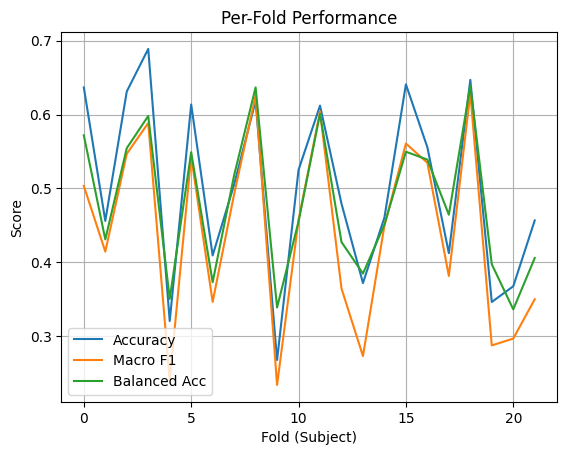


===== FINAL RESULTS =====
Model:             ModelType.CNN
Seed:              42
Accuracy:          0.5011 ± 0.1208
Precision (macro): 0.5131 ± 0.0964
Recall (macro):    0.4807 ± 0.0962
F1 macro:          0.4421 ± 0.1264
Balanced Acc:      0.4807 ± 0.0962
Confusion matrix: [[7321 3550 5289]
 [2216 9630 4840]
 [3266 2887 6322]]


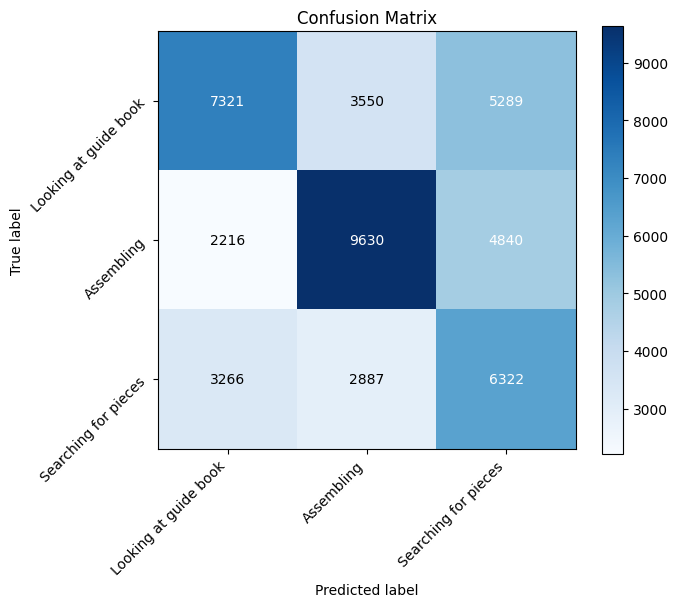

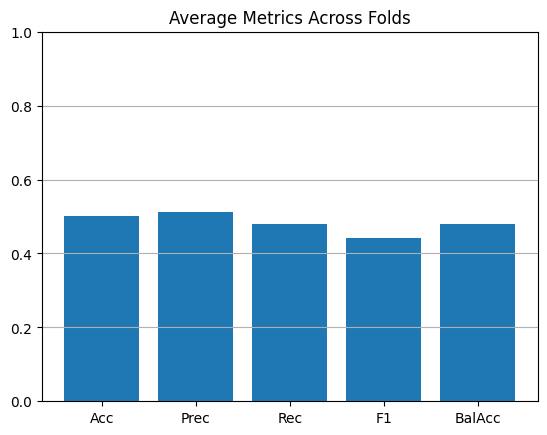

In [19]:
fold_metrics = evaluate_per_fold(per_fold_preds, per_fold_y_test)

final_results = evaluate_final(
    fold_metrics,
    per_fold_preds,
    per_fold_y_test
)